# 텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge

일본의 대형 온라인 쇼핑몰 Mercari 사의 제품에 대해 가격을 예측하는 과제

- 제공 데이터 세트: 제품에 대한 여러 속성 및 제품 설명 등의 텍스트 데이터

- 속성

  - train_id: 데이터 id
  - name: 제품명
  - item_condition_id: 제품 상태
  - category_name: 카테고리 명
  - brand_name: 브랜드 이름
  - price: 제품 가격, target
  - shipping: 배송비 무료 여부 (1이면 무료)
  - item_description: 제품 설명
  

## 데이터 전처리

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
import pandas as pd

mercari_df = pd.read_csv('/content/drive/MyDrive/Euron Homework/kaggle/mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [2]:
print(mercari_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB
None


brand_name -> 매우 많은 Null 값

category_name -> 약 6300 Null 값

item_description -> 4 Null

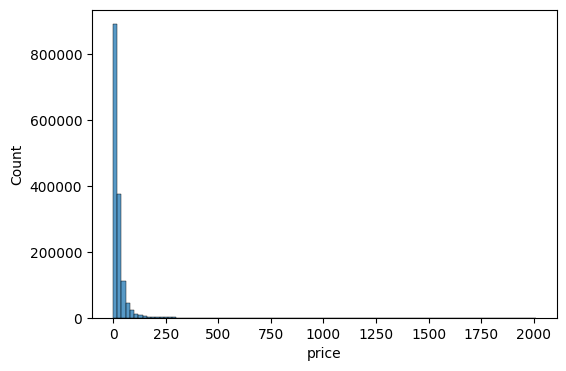

In [3]:
# target 값 데이터 분포도 살펴보기
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

price 값이 비교적 적은 가격을 가진 데이터 값에 왜곡돼 분포되어 있음

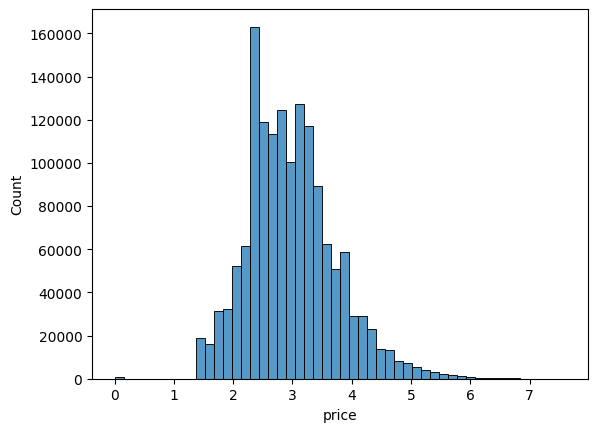

In [4]:
# price를 로그 값으로 변환하기
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [5]:
# 데이터 세트 price 칼럼을 원래 값에서 로그 변환된 값으로 변경하기
mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [6]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n',mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [7]:
boolean_cond = (mercari_df['item_description']=='No description yet')
mercari_df[boolean_cond]['item_description'].count()

np.int64(82489)

In [8]:
# apply lambda에서 호출되는 대 중 소 분할 함수 생성
# 대 중 소 값을 리스트로 반환
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat()을 apply lambda에서 호출해 대 중 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(*mercari_df['category_name'].apply(lambda x:split_cat(x)))

# 대분류의 값의 유형과 건수를 살펴보고, 중분류 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 개수 :\n', mercari_df['cat_jung'].nunique())
print('소분류 개수 :\n', mercari_df['cat_so'].nunique())

대분류 유형 :
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 개수 :
 114
소분류 개수 :
 871


In [9]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 칼럼별로 null 값 건수 확인, 모두 0
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


## 피처 인코딩, 피처 벡터화

### 피처 관찰

mercari price suggestion에 이용되는 데이터 세트는 문자열 칼럼이 많음

- 피처 변환 방식: 예측 모델이 price 값이므로 회귀 모델 기반 -> 선형 회귀 모델, 회귀 트리 모델


- 피처 벡터화: 짧은 텍스트 -> Count 기반, 긴 텍스트 -> TD-IDF

In [10]:
print('brand name의 유형 건수: ', mercari_df['brand_name'].nunique())
print('brand name sample 5건: \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수:  4810
brand name sample 5건: 
 brand_name
Other_Null           632682
PINK                  54088
Nike                  54043
Victoria's Secret     48036
LuLaRoe               31024
Name: count, dtype: int64


대부분 명료한 문자열로 되어 있으므로 별도의 피처 벡터화 형태로 만들지 않고 인코딩 변환 적용

-> 원 핫 인코딩 변환

In [11]:
print('name의 종류 개수: ', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수:  1225273
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


개별적으로 고유한 상품명 -> Count 기반

카테고리 칼럼

shipping 칼럼은 0 1 두 가지 유형,

item_condition_id은 1 2 3 4 5 다섯 가지 유형

-> 모두 원 핫 인코딩

In [12]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print('item_description 평균 문자열 크기:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 크기: 145.71139703278507


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


평균 문자열 크기가 크므로 TF-IDF로 변환하는 것이 좋음

### 인코딩 및 피처 벡터화

In [13]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape: ', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape:  (1482535, 105757)
item_description vectorization shape: (1482535, 50000)


- max_features: (가장 높은 빈도를 가지는 것부터) 추출하는 피처 개수 제한

- ngram_range: 묶어서 피처 추출하는 ngram 범위

CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터를 희소 행렬 형태이다. 희소 행렬 객체 변수인 X_name과 X_descp, 다른 인코딩된 데이터들을 새로 결합해 새로운 데이터 세트를 구성해야 함.

-> 인코딩 대상 칼럼들을 희소 행렬 형태로 인코딩한 뒤 결합하기

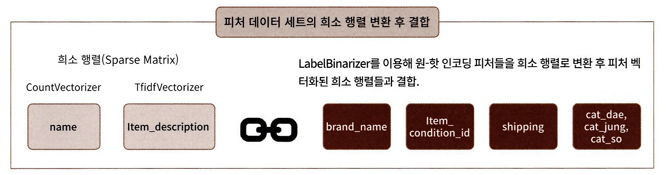

**LabelBinarizer**: 희소 행렬 형태의 원-핫 인코딩 변환 지원 (파라미터 sparse_out=True)

In [14]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_brand_name.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_brand_name.fit_transform(mercari_df['shipping'])

# 카테고리들 각 피처들도 희소 행렬 원핫인코딩
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_brand_name.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_brand_name.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_brand_name.fit_transform(mercari_df['cat_so'])

In [15]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand_shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand_shape:(1482535, 4810), X_item_cond_id shape:(1482535, 5)
X_shipping shape:(1482535, 1), X_cat_dae shape:(1482535, 11)
X_cat_jung shape:(1482535, 114), X_cat_so shape:(1482535, 871)


피처 벡터화 변환된 데이터와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합하기

⚠️ 결합된 데이터가 메모리를 많이 잡아먹으므로 del과 gc.collect()로 결합 데이터를 메모리에서 삭제하고, 그때그때 다시 결합하는 방식을 사용

In [16]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트 모두 결합
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 161569)


0

## 릿지 회귀 모델 구축 및 평가

평가 지표; 캐글의 RMSLE(Root Mean Square Loarithmic Error) 방식

= 오류 값에 로그를 취함

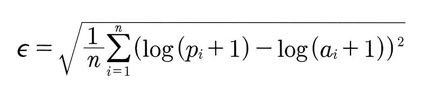

원본 데이터의 price 칼럼 값은 왜곡된 데이터 분포를 가지고 있으므로, 로그 값으로 변환해 정규 분포 형태로 유도

즉, 예측값도 로그로 변환된 값일 것이므로 로그의 역변환인 지수 변환 수행해 원복

In [17]:
def rmsle(y, y_pred):
  # 언더플로우, 오버플로우 막기 위해 log1p로 rmsle 계산
  return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred), 2)))

def evaluate_org_price(y_test, preds):
  # 원본 데이터 원복
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

  # rmsle로 RMSLE 값 추출
  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

In [18]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
  X = hstack(matrix_list).tocsr()

  X_train, X_test, y_train, y_test = train_test_split(X, mercari_df['price'], test_size=0.2, random_state=156)

  # 모델 학습 및 예측
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X, X_train, X_test, y_train
  gc.collect()

  return preds, y_test

릿지를 이용해 mercari price의 회귀 예측 수행

하기 전에

merari 상품 가격 예측에 item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보기

In [19]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('item description을 제외했을 때 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('item description을 포함한 rmsle 값: ', evaluate_org_price(y_test, linear_preds))

item description을 제외했을 때 rmsle 값:  0.4983990938999374
item description을 포함한 rmsle 값:  0.4680432471796771


item description을 포함했을 때 rmsle 값이 많이 감소함 -> 영향력 O

## LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가

In [22]:
import lightgbm

In [20]:
from lightgbm import LGBMRegressor

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
lgbm_preds, y_test = model_train_predict(model = lgbm_model, matrix_list=sparse_matrix_list)
print('LightGBM rmsle 값: ', evaluate_org_price(y_test, lgbm_preds))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
Exception ignored on calling ctypes callback function: <function _log_callback at 0x7f298e4ab420>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/basic.py", line 257, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


Auto-choosing row-wise multi-threading, the overhead of testing was 4102.286814 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1068323
[LightGBM] [Info] Number of data points in the train set: 1186028, number of used features: 65338
[LightGBM] [Info] Start training from score 2.979514


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


LightGBM rmsle 값:  0.4563962127849484


In [21]:
preds = lgbm_preds * 0.45 + linear_preds*0.55
print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값: ', evaluate_org_price(y_test, preds))

LightGBM과 Ridge를 ensemble한 최종 rmsle 값:  0.4467272727321774
